<a href="https://colab.research.google.com/github/AngelaB111/SMS-Spam-Detection-Python-/blob/main/spamDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:110: SyntaxWarning: invalid escape sequence '\s'
<>:110: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2511561423.py:110: SyntaxWarning: invalid escape sequence '\s'
  processed_message = re.sub('[^a-zA-Z0-9\s]', '', processed_message)


        v1                                                 v2
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham            Will ï¿½_ b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]
      label                                            message
0         0  go until jurong point crazy available only in ...
1         0                            ok lar joking wif u oni
2         1  free entry in 2 a wkly comp t

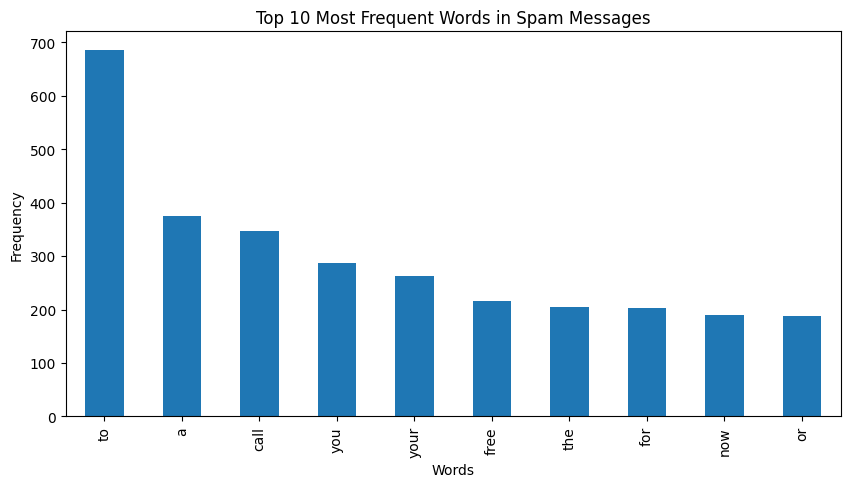

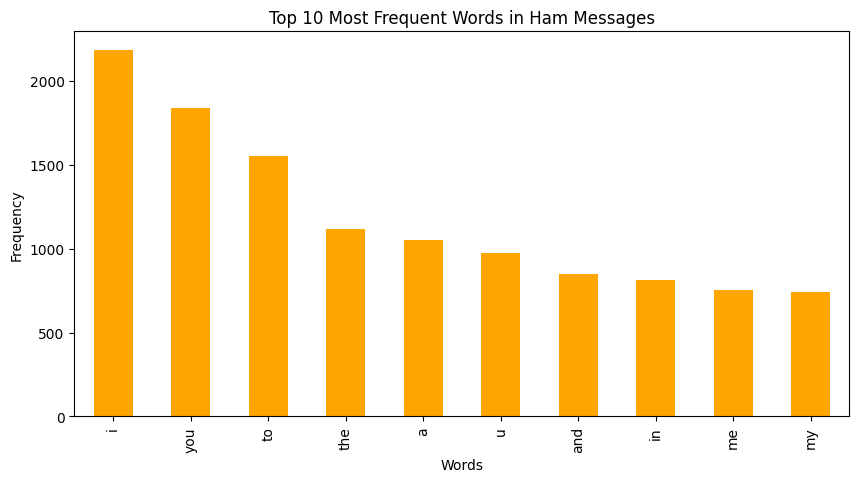

Naive Bayes:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.88      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9820627802690582

Random Forest:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Accuracy: 0.9713004484304932


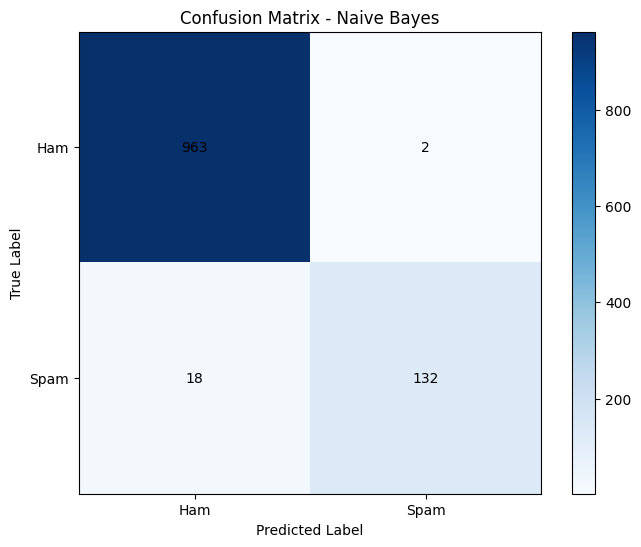

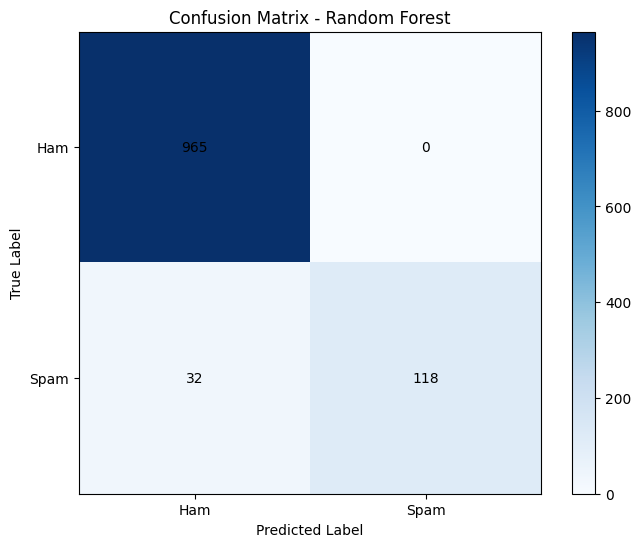

Message: Congratulations! You've won a free prize!
Naive Bayes Prediction: Spam
Random Forest Prediction: Spam
--------------------
Message: Hey, what's up?
Naive Bayes Prediction: Ham
Random Forest Prediction: Ham
--------------------
Message: Free entry to a contest!
Naive Bayes Prediction: Spam
Random Forest Prediction: Ham
--------------------
Message: Your order has been shipped.
Naive Bayes Prediction: Spam
Random Forest Prediction: Ham
--------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
except FileNotFoundError:
    print("Error: 'spam.csv' not found. Please upload the file to the current directory.")
    exit()

print(df)

# Preprocessing
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df['message'] = df['message'].str.lower()
df['message'] = df['message'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)


# Word frequency analysis
spam_words = ' '.join(df[df['label'] == 1]['message']).split()
ham_words = ' '.join(df[df['label'] == 0]['message']).split()

spam_word_freq = pd.Series(spam_words).value_counts()
ham_word_freq = pd.Series(ham_words).value_counts()

print(df)
# Visualization (using Matplotlib)
plt.figure(figsize=(10, 5))
spam_word_freq[:10].plot(kind='bar')
plt.title('Top 10 Most Frequent Words in Spam Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
ham_word_freq[:10].plot(kind='bar', color='orange')
plt.title('Top 10 Most Frequent Words in Ham Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

# Feature extraction
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train models
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_vec, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test_vec)
rf_pred = rf_model.predict(X_test_vec)

# Evaluate models
print("Naive Bayes:")
print(classification_report(y_test, nb_pred))
print(f"Accuracy: {accuracy_score(y_test, nb_pred)}")

print("\nRandom Forest:")
print(classification_report(y_test, rf_pred))
print(f"Accuracy: {accuracy_score(y_test, rf_pred)}")

# Confusion matrices (using Matplotlib)
#Naive Bayes
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, nb_pred)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Naive Bayes')
plt.colorbar()
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()
#random forest
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Random Forest')
plt.colorbar()
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

import re

def predict_message(message, model, vectorizer):
    processed_message = message.lower()
    # Use re.sub for regex replacement
    processed_message = re.sub('[^a-zA-Z0-9\s]', '', processed_message)
    message_vec = vectorizer.transform([processed_message])
    prediction = model.predict(message_vec)[0]
    return prediction

# Example usage (you can change the messages)
messages = [
    "Congratulations! You've won a free prize!",
    "Hey, what's up?",
    "Free entry to a contest!",
    "Your order has been shipped."
    ]

for message in messages:
    nb_prediction = predict_message(message, nb_model, vectorizer)
    rf_prediction = predict_message(message, rf_model, vectorizer)
    print(f"Message: {message}")
    print(f"Naive Bayes Prediction: {'Spam' if nb_prediction == 1 else 'Ham'}")
    print(f"Random Forest Prediction: {'Spam' if rf_prediction == 1 else 'Ham'}")
    print("-" * 20)